In [1]:
!nvidia-smi -L


GPU 0: Tesla T4 (UUID: GPU-3ac2f2eb-96bc-a035-f737-df9c456c711a)


In [2]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

--2026-04-06 07:16:55--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-04-06 07:16:56 (112 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [4]:
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys

In [5]:
import tensorflow_datasets as tfds

In [6]:
datasets_list = tfds.list_builders()
datasets_list

['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'ai2dcaption',
 'aloha_mobile',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence',
 'arc',
 'asimov_dilemmas_auto_val',
 'asimov_dilemmas_scifi_train',
 'asimov_dilemmas_scifi_val',
 'asimov_injury_val',
 'asimov_multimodal_auto_val',
 'asimov_multimodal_manual_val',
 'asqa',
 'asset',
 'assin2',
 'asu_table_top_converted_externally_to_rlds',
 'austin_buds_dataset_converted_externally_to_rlds',
 'austin_sailor_dataset_converted_externally_to_rlds',
 'austin_sirius_dataset_converted_externally_to_rlds',
 'bair_robot_pushing_small',
 'bc_z',
 'bccd',
 'beans',
 'bee_dataset',
 'beir',
 'berkeley_autolab_ur5',
 'berkeley_cable_routing',
 'berkeley_fanuc_manipulation',
 'berkeley_gnm_cory_hall',
 'berkeley_gnm_recon',
 'berkeley_gnm_sac_son',
 'berkeley_mvp_converted_externally_to_rlds',
 'berkeley_rpt_converted_externally_to_rlds',
 'big_patent',
 'bigearthnet',
 'billsum',
 '

In [ ]:
(train_data, test_data), ds_info = tfds.load(
    name='food101',
    split=['train', 'validation'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

In [ ]:
ds_info.features

In [ ]:
class_names = ds_info.features['label'].names
class_names[:10]

In [ ]:
train_one_sample = train_data.take(1)
train_one_sample

In [ ]:
for image, label in train_one_sample:
  print(
      f'''
      Image shape: {image.shape}
      Image dtype: {image.dtype}
      Target class from Food101 (tensor form): {label}
      Class name (str form): {class_names[label.numpy()]}
      '''
  )

In [ ]:
image

In [ ]:
import tensorflow as tf
tf.reduce_min(image), tf.reduce_max(image)

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis(False)
plt.title(f'class name: {class_names[label.numpy()]}')
plt.figure(figsize=(10, 7))


In [ ]:
def preprocess_image(image, label, img_shape=224):
  image = tf.image.resize(image, size=[img_shape, img_shape])
  return tf.cast(image, tf.float32), label

In [ ]:
preprocessed_image = preprocess_image(image, label)[0]
print(f'''
image before preprocessing: {image[:2]},\n shape :{image.shape},\n data type:{image.dtype}\n
''')
print(f'''image after preprocessing: {preprocessed_image[:2]},\n shape :{preprocessed_image.shape},\n data type:{preprocessed_image.dtype}\n
''')


In [ ]:
train_data = train_data.map(map_func=preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_data = train_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

test_data = test_data.map(map_func=preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size=32).prefetch(tf.data.AUTOTUNE)

In [ ]:
train_data, test_data

In [ ]:
from helper_functions import create_tensorboard_callback

checkpoint_path = 'model_checkpoints.weights.h5'
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)

In [21]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

In [24]:
from tensorflow.keras import layers
from tensorflow.keras import preprocessing

input_shape = (224,224,3)

base_model = tf.keras.applications.EfficientNetV2B3(include_top=False)
base_model.trainable = False

inputs = layers.Input(shape=input_shape, name='input_layer')
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='global_average_pooling_layer')(x)
x = layers.Dense(len(class_names))(x)
outputs = layers.Activation('softmax', dtype=tf.float32, name='softmax_float32')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [25]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 7, 7, 1536)     │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │       155,237 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,085,859 (49.92 MB)

 Trainable params: 155,237 (606.39 KB)

 Non-trainable params: 12,930,622 (49.33 MB)

In [31]:
for layer in model.layers:
  print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer True float32 <DTypePolicy "mixed_float16">
efficientnetv2-b3 False float32 <DTypePolicy "mixed_float16">
global_average_pooling_layer True float32 <DTypePolicy "mixed_float16">
dense True float32 <DTypePolicy "mixed_float16">
softmax_float32 True float32 <DTypePolicy "float32">


In [34]:
for layer in model.layers[1].layers[:20]:
  print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer False float32 <DTypePolicy "mixed_float16">
rescaling False float32 <DTypePolicy "mixed_float16">
normalization False float32 <DTypePolicy "mixed_float16">
stem_conv False float32 <DTypePolicy "mixed_float16">
stem_bn False float32 <DTypePolicy "mixed_float16">
stem_activation False float32 <DTypePolicy "mixed_float16">
block1a_project_conv False float32 <DTypePolicy "mixed_float16">
block1a_project_bn False float32 <DTypePolicy "mixed_float16">
block1a_project_activation False float32 <DTypePolicy "mixed_float16">
block1b_project_conv False float32 <DTypePolicy "mixed_float16">
block1b_project_bn False float32 <DTypePolicy "mixed_float16">
block1b_project_activation False float32 <DTypePolicy "mixed_float16">
block1b_drop False float32 <DTypePolicy "mixed_float16">
block1b_add False float32 <DTypePolicy "mixed_float16">
block2a_expand_conv False float32 <DTypePolicy "mixed_float16">
block2a_expand_bn False float32 <DTypePolicy "mixed_float16">
block2a_expand_activation Fal

In [36]:
history_101_food_classes_extract_model=model.fit(
    train_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=int(0.15 * len(test_data)),
    callbacks=[
        create_tensorboard_callback(dir_name='training_logs', experiment_name='efficientnetv2b3'),
        model_checkpoint
    ]
)

Saving TensorBoard log files to: training_logs/efficientnetv2b3/20260406-085514
Epoch 1/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 225s 94ms/step - accuracy: 0.5923 - loss: 1.5969 - val_accuracy: 0.6939 - val_loss: 1.1362
Epoch 2/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 164s 68ms/step - accuracy: 0.6433 - loss: 1.3774 - val_accuracy: 0.7121 - val_loss: 1.0545
Epoch 3/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 177s 74ms/step - accuracy: 0.6662 - loss: 1.2688 - val_accuracy: 0.7174 - val_loss: 1.0076
Epoch 4/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 166s 69ms/step - accuracy: 0.6813 - loss: 1.2037 - val_accuracy: 0.7198 - val_loss: 0.9912
Epoch 5/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 164s 68ms/step - accuracy: 0.6932 - loss: 1.1540 - val_accuracy: 0.7352 - val_loss: 0.9713


In [46]:
model.evaluate(test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 64s 81ms/step - accuracy: 0.7817 - loss: 0.7906


[0.7905568480491638, 0.7817425727844238]

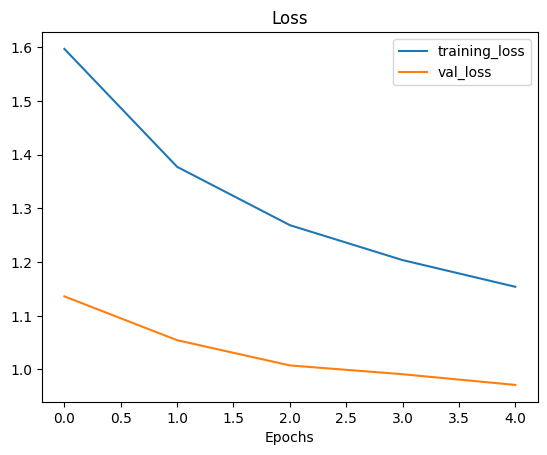

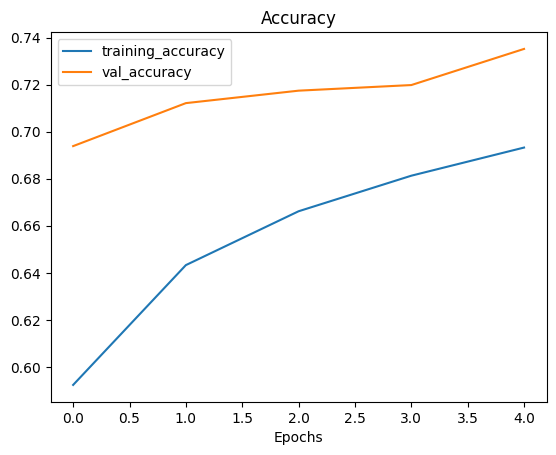

In [38]:
plot_loss_curves(history_101_food_classes_extract_model)

In [40]:
base_model.trainable =True

In [43]:
for layer in base_model.layers[:-10]:
  layer.trainable = False

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

In [44]:
history_101_food_classes_fine_tune_1 = model.fit(
    train_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=int(0.15 * len(test_data)),
    callbacks=[
        create_tensorboard_callback(dir_name='training_logs', experiment_name='efficientnetv2b3_fine_tune_1'), model_checkpoint]
)

Saving TensorBoard log files to: training_logs/efficientnetv2b3_fine_tune_1/20260406-092137
Epoch 1/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 289s 95ms/step - accuracy: 0.7142 - loss: 1.0882 - val_accuracy: 0.7606 - val_loss: 0.8602
Epoch 2/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 167s 70ms/step - accuracy: 0.7425 - loss: 0.9643 - val_accuracy: 0.7707 - val_loss: 0.8209
Epoch 3/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 202s 70ms/step - accuracy: 0.7605 - loss: 0.8956 - val_accuracy: 0.7778 - val_loss: 0.8054
Epoch 4/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 169s 70ms/step - accuracy: 0.7742 - loss: 0.8370 - val_accuracy: 0.7783 - val_loss: 0.7898
Epoch 5/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 168s 70ms/step - accuracy: 0.7852 - loss: 0.7960 - val_accuracy: 0.7852 - val_loss: 0.7685


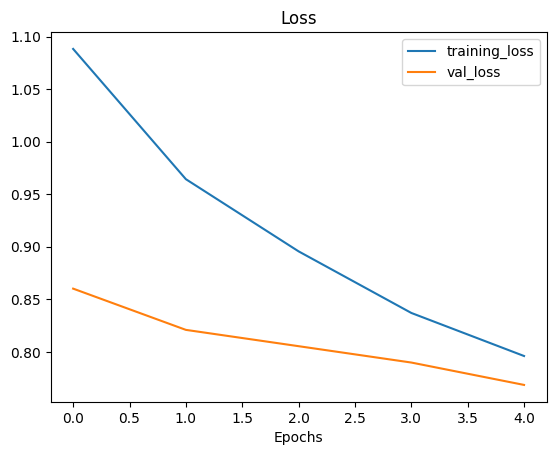

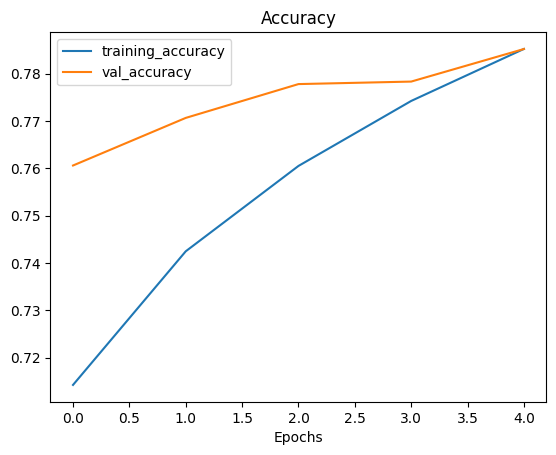

In [47]:
plot_loss_curves(history_101_food_classes_fine_tune_1)

In [48]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

In [49]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3)

In [50]:
history_101_food_classes_fine_tune_2 = model.fit(
    train_data,
    epochs=10,
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=int(0.15 * len(test_data)),
    callbacks=[
        create_tensorboard_callback(dir_name='training_logs', experiment_name='efficientnetv2b3_fine_tune_1'), model_checkpoint, early_stop, reduce_lr]
)

Saving TensorBoard log files to: training_logs/efficientnetv2b3_fine_tune_1/20260406-100141
Epoch 1/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 167s 69ms/step - accuracy: 0.7955 - loss: 0.7592 - val_accuracy: 0.7860 - val_loss: 0.7589 - learning_rate: 1.0000e-04
Epoch 2/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 202s 69ms/step - accuracy: 0.8034 - loss: 0.7217 - val_accuracy: 0.7871 - val_loss: 0.7593 - learning_rate: 1.0000e-04
Epoch 3/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 203s 84ms/step - accuracy: 0.8127 - loss: 0.6893 - val_accuracy: 0.7918 - val_loss: 0.7524 - learning_rate: 1.0000e-04
Epoch 4/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 164s 68ms/step - accuracy: 0.8192 - loss: 0.6624 - val_accuracy: 0.7905 - val_loss: 0.7603 - learning_rate: 1.0000e-04
Epoch 5/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 167s 70ms/step - accuracy: 0.8272 - loss: 0.6379 - val_accuracy: 0.7961 - val_loss: 0.7362 - learning_rate: 1.0000e-04
Epoch 6/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 209s 72ms/step - accuracy: 0.8338 - loss: 0.6095 - val_accura

In [51]:
model.evaluate(test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.7974 - loss: 0.7373


[0.7372639775276184, 0.7974257469177246]

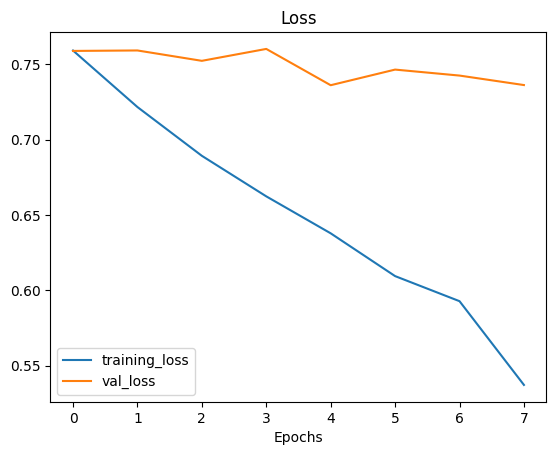

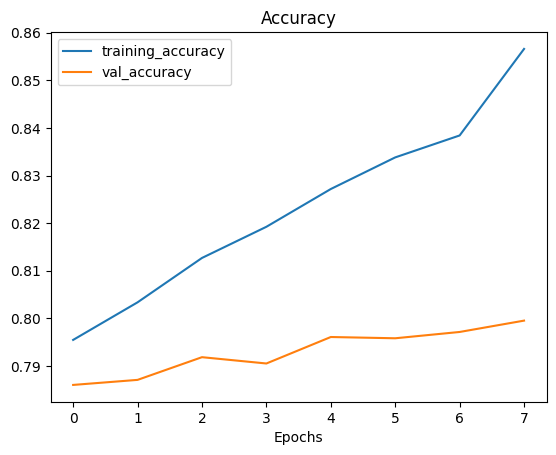

In [52]:
plot_loss_curves(history_101_food_classes_fine_tune_2)

In [54]:
base_model.trainable = True

In [55]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    metrics=['accuracy']
)

In [56]:
history_101_food_classes_fine_tune_3 = model.fit(
    train_data,
    epochs=20,
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=int(0.15 * len(test_data)),
    callbacks=[
        create_tensorboard_callback(dir_name='training_logs', experiment_name='efficientnetv2b3_fine_tune_1'), model_checkpoint, early_stop, reduce_lr]
)

Saving TensorBoard log files to: training_logs/efficientnetv2b3_fine_tune_1/20260406-104134
Epoch 1/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 288s 93ms/step - accuracy: 0.8604 - loss: 0.5256 - val_accuracy: 0.7977 - val_loss: 0.7337 - learning_rate: 1.0000e-05
Epoch 2/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 170s 71ms/step - accuracy: 0.8606 - loss: 0.5226 - val_accuracy: 0.8008 - val_loss: 0.7269 - learning_rate: 1.0000e-05
Epoch 3/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 169s 70ms/step - accuracy: 0.8603 - loss: 0.5231 - val_accuracy: 0.8006 - val_loss: 0.7239 - learning_rate: 1.0000e-05
Epoch 4/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 167s 70ms/step - accuracy: 0.8616 - loss: 0.5182 - val_accuracy: 0.8014 - val_loss: 0.7222 - learning_rate: 1.0000e-05
Epoch 5/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 164s 68ms/step - accuracy: 0.8635 - loss: 0.5135 - val_accuracy: 0.7982 - val_loss: 0.7326 - learning_rate: 1.0000e-05
Epoch 6/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8652 - loss: 0.5118
Epoch 6: Reduc